In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import StandardScaler, label_binarize
import xgboost as xgb

print("Imports done.")
print("XGBoost version:", xgb.__version__)

Imports done.
XGBoost version: 3.2.0


In [2]:
df = pd.read_csv("cmi_module1_clean-1.csv")

print("Shape:", df.shape)
print("\nsii distribution:")
print(df["sii"].value_counts().sort_index())
print("\nsii distribution (%):")
print((df["sii"].value_counts(normalize=True).sort_index() * 100).round(1))

Shape: (8417, 32)

sii distribution:
sii
0.0    5806
1.0    1578
2.0     947
3.0      86
Name: count, dtype: int64

sii distribution (%):
sii
0.0    69.0
1.0    18.7
2.0    11.3
3.0     1.0
Name: proportion, dtype: float64


In [3]:
X = df.drop(columns=["sii"])
y = df["sii"].astype(int)  # XGBoost needs integer labels

# Stratified split — same as teammates
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train shape: (6733, 31)
Test shape: (1684, 31)

Train class distribution:
sii
0    4644
1    1262
2     758
3      69
Name: count, dtype: int64

Test class distribution:
sii
0    1162
1     316
2     189
3      17
Name: count, dtype: int64


hyper parameter tunning

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    xgb_model, param_grid,
    cv=skf, scoring='f1_macro',
    n_jobs=-1, verbose=1
)

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
grid_xgb.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", grid_xgb.best_params_)
print("Best CV F1 Macro:", round(grid_xgb.best_score_, 4))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 Macro: 0.3514


evaluate on test set

In [5]:
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["None", "Mild", "Moderate", "Severe"],
      zero_division=0))

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Macro:  {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

        None       0.79      0.73      0.76      1162
        Mild       0.31      0.35      0.33       316
    Moderate       0.25      0.30      0.27       189
      Severe       0.05      0.06      0.05        17

    accuracy                           0.60      1684
   macro avg       0.35      0.36      0.35      1684
weighted avg       0.63      0.60      0.62      1684

Accuracy:  0.6039
Precision: 0.3480
Recall:    0.3598
F1 Macro:  0.3525


confusion matrix

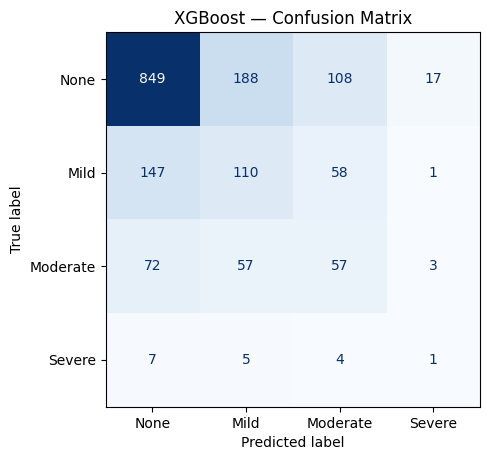

In [6]:
fig, ax = plt.subplots(figsize=(5, 6))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["None", "Mild", "Moderate", "Severe"]).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

almost everything is predicted as None. now, let's plot the roc curve

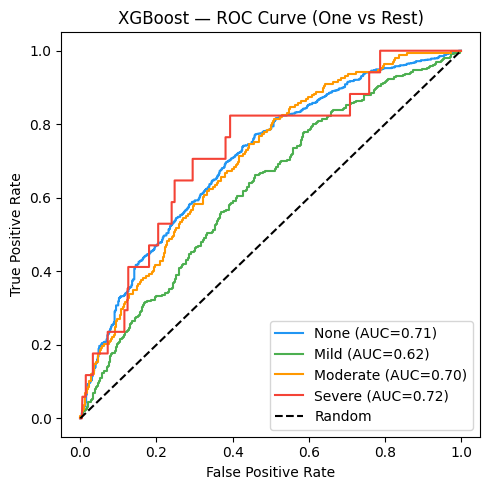

In [7]:
y_prob = best_xgb.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
class_names = ['None', 'Mild', 'Moderate', 'Severe']

plt.figure(figsize=(5, 5))
for i, (color, name) in enumerate(zip(colors, class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (One vs Rest)")
plt.legend()
plt.tight_layout()
plt.show()

features importance

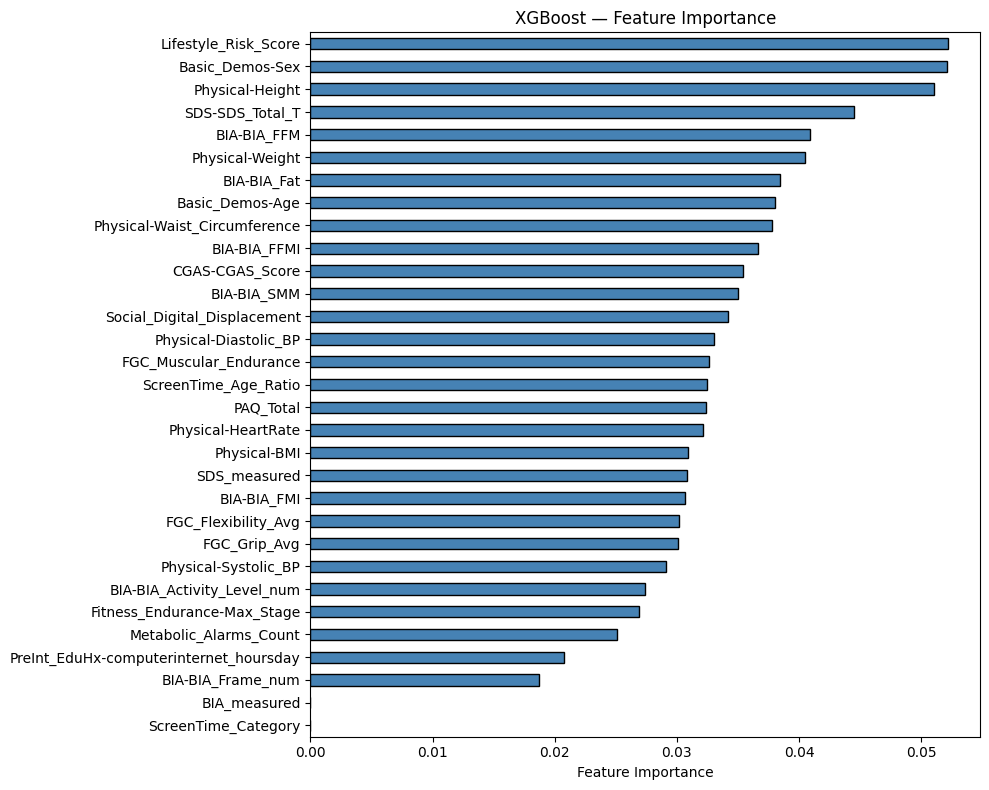


Top 10 most important features:
Lifestyle_Risk_Score            0.0522
Basic_Demos-Sex                 0.0521
Physical-Height                 0.0510
SDS-SDS_Total_T                 0.0445
BIA-BIA_FFM                     0.0409
Physical-Weight                 0.0405
BIA-BIA_Fat                     0.0384
Basic_Demos-Age                 0.0380
Physical-Waist_Circumference    0.0378
BIA-BIA_FFMI                    0.0367
dtype: float32


In [8]:
xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
xgb_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel("Feature Importance")
plt.title("XGBoost — Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(xgb_importance.head(10).round(4))

cross validation score

In [9]:
from sklearn.metrics import make_scorer

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0)
}

cv_results = cross_validate(
    best_xgb, X_train, y_train,
    cv=skf, scoring=scoring, n_jobs=-1
)

print("XGBoost — 5-Fold Stratified CV Results:")
print(f"Accuracy:    {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision:   {cv_results['test_precision_macro'].mean():.4f} ± {cv_results['test_precision_macro'].std():.4f}")
print(f"Recall:      {cv_results['test_recall_macro'].mean():.4f} ± {cv_results['test_recall_macro'].std():.4f}")
print(f"F1 Macro:    {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"F1 Weighted: {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

XGBoost — 5-Fold Stratified CV Results:
Accuracy:    0.6887 ± 0.0067
Precision:   0.3642 ± 0.0233
Recall:      0.2990 ± 0.0069
F1 Macro:    0.2983 ± 0.0105
F1 Weighted: 0.6207 ± 0.0094


n_estimator on F1 score

n_estimators=10: F1 Macro = 0.2041
n_estimators=50: F1 Macro = 0.2559
n_estimators=100: F1 Macro = 0.2830
n_estimators=150: F1 Macro = 0.2957
n_estimators=200: F1 Macro = 0.2992
n_estimators=300: F1 Macro = 0.2966
n_estimators=500: F1 Macro = 0.2986


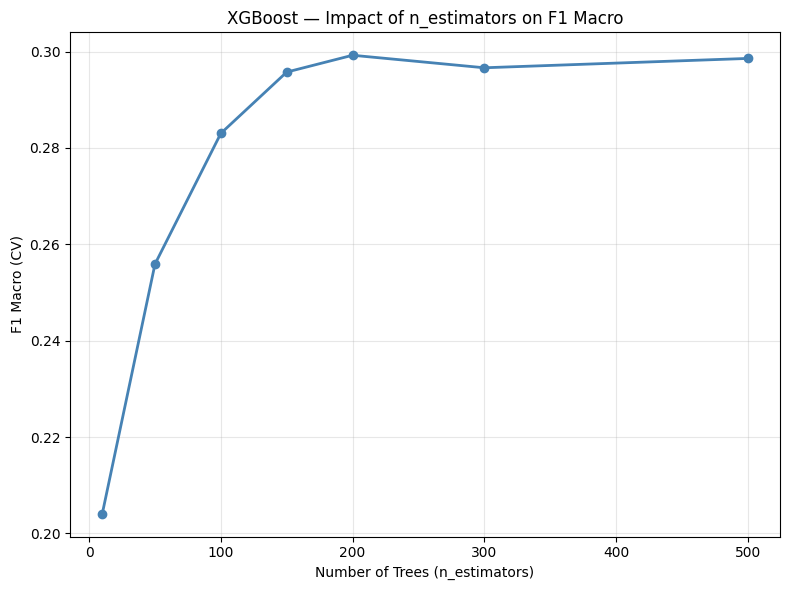

In [10]:
from sklearn.model_selection import cross_val_score

n_estimators_range = [10, 50, 100, 150, 200, 300, 500]
f1_scores = []

for n in n_estimators_range:
    model = xgb.XGBClassifier(
        n_estimators=n,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=4,
        random_state=42,
        eval_metric='mlogloss'
    )
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    f1_scores.append(scores.mean())
    print(f"n_estimators={n}: F1 Macro = {scores.mean():.4f}")

plt.figure(figsize=(8, 6))
plt.plot(n_estimators_range, f1_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("F1 Macro (CV)")
plt.title("XGBoost — Impact of n_estimators on F1 Macro")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precision-recall curve

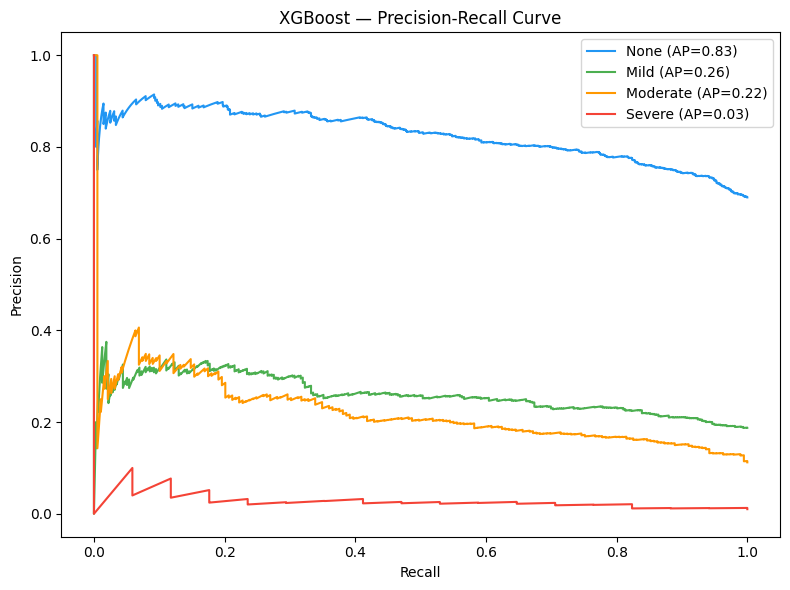

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score

class_names = ['None', 'Mild', 'Moderate', 'Severe']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, color=color, label=f'{name} (AP={ap:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)',
               'F1 Macro', 'F1 Weighted'],
    'CV Score': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_f1_weighted'].mean()
    ],
    'CV Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_f1_weighted'].std()
    ],
    'Test Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro', zero_division=0),
        recall_score(y_test, y_pred, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0)
    ]
}).round(4)

print("XGBoost — Final Summary Table")
print(summary.to_string(index=False))

XGBoost — Final Summary Table
           Metric  CV Score  CV Std  Test Score
         Accuracy    0.6887  0.0067      0.6039
Precision (Macro)    0.3642  0.0233      0.3480
   Recall (Macro)    0.2990  0.0069      0.3598
         F1 Macro    0.2983  0.0105      0.3525
      F1 Weighted    0.6207  0.0094      0.6161


LIME

In [13]:
!pip install lime -q

import lime
import lime.lime_tabular

print("LIME imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME imported successfully.


In [14]:
# Create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['None', 'Mild', 'Moderate', 'Severe'],
    mode='classification',
    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


In [15]:
# Explain prediction for sample index 0
sample_idx = 0
sample = X_test.iloc[sample_idx].values

explanation = explainer_lime.explain_instance(
    data_row=sample,
    predict_fn=best_xgb.predict_proba,
    num_features=10
)

print(f"Actual sii: {y_test.iloc[sample_idx]}")
print(f"XGBoost predicted: {best_xgb.predict(X_test.iloc[[sample_idx]])[0]}")
print(f"\nTop 10 features explaining this prediction:")
for feat, weight in explanation.as_list():
    print(f"  {feat}: {weight:.4f}")

Actual sii: 0
XGBoost predicted: 0

Top 10 features explaining this prediction:
  Physical-Height <= 55.00: -0.0529
  Physical-HeartRate > 86.00: 0.0434
  PAQ_Total <= 2.00: -0.0408
  BIA-BIA_FMI > 5.18: 0.0382
  Basic_Demos-Sex <= 0.00: 0.0316
  109.00 < Physical-Systolic_BP <= 114.00: -0.0228
  16.75 < Physical-BMI <= 17.94: 0.0227
  13.81 < BIA-BIA_FFMI <= 14.09: -0.0225
  1.00 < BIA-BIA_Frame_num <= 2.00: 0.0223
  54.50 < SDS-SDS_Total_T <= 55.00: -0.0217


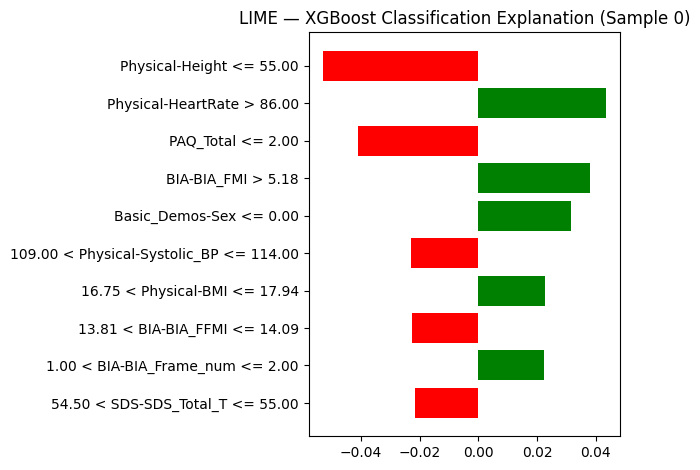

In [16]:
explanation.as_pyplot_figure()
plt.title("LIME — XGBoost Classification Explanation (Sample 0)")
plt.tight_layout()
plt.show()

Actual sii: 2
XGBoost predicted: 0

Top 10 features:
  Basic_Demos-Age <= 7.00: -0.0684
  BIA-BIA_FFMI <= 13.81: 0.0555
  Physical-Height <= 55.00: -0.0529
  PAQ_Total > 2.30: 0.0458
  Physical-Systolic_BP <= 109.00: 0.0416
  Lifestyle_Risk_Score <= 0.88: -0.0413
  Physical-Weight <= 58.00: -0.0369
  65.00 < CGAS-CGAS_Score <= 70.00: -0.0347
  SDS-SDS_Total_T > 56.00: 0.0343
  Basic_Demos-Sex <= 0.00: 0.0269


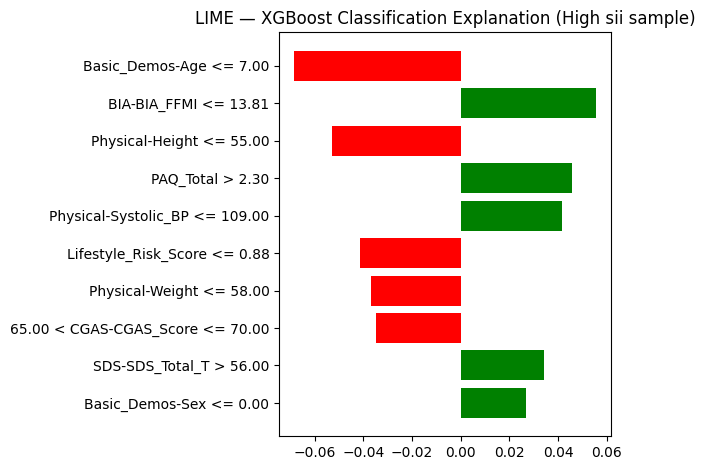

In [17]:
# Find a sample with actual sii=2 or 3
high_sii_idx = y_test[y_test >= 2].index[0]
sample_pos = X_test.index.get_loc(high_sii_idx)

explanation2 = explainer_lime.explain_instance(
    data_row=X_test.iloc[sample_pos].values,
    predict_fn=best_xgb.predict_proba,
    num_features=10
)

print(f"Actual sii: {y_test.iloc[sample_pos]}")
print(f"XGBoost predicted: {best_xgb.predict(X_test.iloc[[sample_pos]])[0]}")
print(f"\nTop 10 features:")
for feat, weight in explanation2.as_list():
    print(f"  {feat}: {weight:.4f}")

explanation2.as_pyplot_figure()
plt.title(f"LIME — XGBoost Classification Explanation (High sii sample)")
plt.tight_layout()
plt.show()